# The density matrix renormalisation group

Companion notebook to the chapter on the density matrix renormalisation
group of *Quantum mechanics for many-particle systems*.  The code is the
same as in `BookManybody/BookPrograms/chapterdmrg/dmrg.py`.

The full configuration-interaction calculations of the earlier chapters
store a state as one amplitude per Slater determinant, and the number of
determinants grows exponentially with the number of single-particle
levels.  The DMRG stores a state instead as a **matrix product state**
(MPS),

$$|\Psi\rangle=\sum_{s_1\cdots s_L}
  A^{s_1}_{[1]}A^{s_2}_{[2]}\cdots A^{s_L}_{[L]}\,|s_1 s_2\cdots s_L\rangle ,$$

a product of matrices of size at most $\chi\times\chi$, one per site of a
chain, and optimises the matrices one bond at a time.  The Schmidt
decomposition of Chapter 1 is applied at every bond in turn; truncating it
to the $\chi$ largest Schmidt values is what makes the method polynomial,
and the discarded weight tells us what the truncation cost.

The three models of the book are mapped on a chain by treating each
doubly-degenerate level $p$ as one site with the four states
$|0\rangle$, $|{\uparrow}\rangle$, $|{\downarrow}\rangle$ and
$|{\uparrow\downarrow}\rangle$, with the Jordan-Wigner strings of Chapter 3
taking care of the fermionic signs.  The Hamiltonians are written as
**matrix product operators** (MPO) built automatically from the list of
operator strings that also defines the exact diagonalisation, so that the
two methods are guaranteed to solve the same problem.

Contents:

1. Sites, modes and Jordan-Wigner strings
2. Matrix product operators of the three models
3. The pairing model: the energies of Chapter 4 and the entropy of Chapter 1
4. The pairing plus particle-hole model: convergence and extrapolation
5. The Hubbard chain: beyond exact diagonalisation

In [1]:
import sys, os, glob, time
import numpy as np
import matplotlib.pyplot as plt

# the chapter programs live in BookPrograms/chapterNN (and chapterdmrg);
# put them all on the path
for _pattern in ("chapter*", "appendix*"):
    for _d in sorted(glob.glob(os.path.join("..", "BookManybody",
                                            "BookPrograms", _pattern))):
        if _d not in sys.path:
            sys.path.insert(0, _d)
import dmrg
from dmrg import (pairing_terms, particle_hole_terms, hubbard_terms,
                  number_penalty_terms, number_terms, occupation_terms,
                  add_terms, build_mpo, mpo_bond_dimensions, mpo_dense,
                  exact_ground_state, sector_states, sparse_hamiltonian,
                  chain_index, MPS, DMRG, dmrg_ground_state,
                  entanglement_entropy, lieb_wu_energy, mode)

np.set_printoptions(precision=6, suppress=True, linewidth=120)

## 1. Sites, modes and Jordan-Wigner strings

A site carries two modes, $a$ (spin up, or the time-reversal partner
$+$ of the pairing model) and $b$ (spin down, or $-$), so the local space
is $d=4$.  Inside the site the creation operators are
$c^\dagger_a=\sigma^+\otimes I$ and $c^\dagger_b=\sigma^z\otimes\sigma^+$,
which anticommute; between sites the Jordan-Wigner string is the parity
$(-1)^{n_a+n_b}$ of every site to the left.  Let us verify the
anticommutation relations on one site, and that a two-site product with
the string in place anticommutes across sites.

In [2]:
I4 = np.eye(4)
ops = {"c_a": dmrg.C_A, "c_b": dmrg.C_B}
print("one site, {c_i, c_j^+} = delta_ij and {c_i, c_j} = 0:")
for ni, ci in ops.items():
    for nj, cj in ops.items():
        acomm = ci @ cj.T + cj.T @ ci
        print(f"  {{{ni}, {nj}^+}} = delta_ij: {np.allclose(acomm, I4 * (ni == nj))},"
              f"   {{{ni}, {nj}}} = 0: {np.allclose(ci @ cj + cj @ ci, 0)}")

# two sites: c on site 1 must carry the parity of site 0
c0 = np.kron(dmrg.C_A, I4)
c1 = np.kron(dmrg.PARITY, dmrg.C_A)          # string on the site to the left
c1_bad = np.kron(I4, dmrg.C_A)               # without the string
print("two sites: {c_0, c_1} = 0 with the string:", np.allclose(c0 @ c1 + c1 @ c0, 0),
      "  without the string:", np.allclose(c0 @ c1_bad + c1_bad @ c0, 0))

one site, {c_i, c_j^+} = delta_ij and {c_i, c_j} = 0:
  {c_a, c_a^+} = delta_ij: True,   {c_a, c_a} = 0: True
  {c_a, c_b^+} = delta_ij: True,   {c_a, c_b} = 0: True
  {c_b, c_a^+} = delta_ij: True,   {c_b, c_a} = 0: True
  {c_b, c_b^+} = delta_ij: True,   {c_b, c_b} = 0: True
two sites: {c_0, c_1} = 0 with the string: True   without the string: False


## 2. Matrix product operators of the three models

Every Hamiltonian of the chapter is a list of terms, each a coefficient
and a string of creation and annihilation operators on the $2L$ modes.
`build_mpo` converts the list into an MPO: each string becomes a product
of one $4\times4$ operator per site (with the parity on the sites the
string passes over), and the sum of these products is compressed bond by
bond with the SVD, so that the bond dimension is the smallest one that
represents the operator exactly.  The pairing interaction
$-\tfrac{g}{2}\sum_{pq}P^+_pP^-_q$ is a product of two sums and needs the
four automaton states *nothing placed*, *$P^+$ placed*, *$P^-$ placed*,
*done*; the particle-hole interaction with its Jordan-Wigner strings needs
more; a periodic bond has to be carried across the whole chain.

In [3]:
L = 6
for name, terms in (("pairing, g = 1", pairing_terms(L, 1.0)),
                    ("pairing + particle-hole, g = 1, f = 0.5",
                     add_terms(pairing_terms(L, 1.0), particle_hole_terms(L, 0.5))),
                    ("Hubbard chain, open, U = 4", hubbard_terms(L, 1.0, 4.0)),
                    ("Hubbard ring, periodic, U = 4", hubbard_terms(L, 1.0, 4.0, pbc=True)),
                    ("number penalty (N - 6)^2", number_penalty_terms(L, 6, 1.0))):
    W = build_mpo(terms, L)
    print(f"  {name:42s} terms = {len(terms):5d}   "
          f"MPO bond dimensions {mpo_bond_dimensions(W)}")

  pairing, g = 1                             terms =    48   MPO bond dimensions [4, 4, 4, 4, 4]
  pairing + particle-hole, g = 1, f = 0.5    terms =   480   MPO bond dimensions [12, 14, 14, 14, 12]
  Hubbard chain, open, U = 4                 terms =    26   MPO bond dimensions [6, 6, 6, 6, 6]
  Hubbard ring, periodic, U = 4              terms =    30   MPO bond dimensions [6, 10, 10, 10, 6]
  number penalty (N - 6)^2                   terms =   157   MPO bond dimensions [3, 3, 3, 3, 3]


The MPO and the sparse Hamiltonian of the exact diagonalisation are built
from the same list; for three sites we can form the dense $64\times64$
matrix of the MPO and compare it with the Hamiltonian in the $N=3$
sector.

In [4]:
L = 3
terms = add_terms(pairing_terms(L, 1.0), particle_hole_terms(L, 0.5))
H = mpo_dense(build_mpo(terms, L))
states = sector_states(L, 3)
Hs = sparse_hamiltonian(terms, L, states).toarray()
idx = np.array([chain_index(st, L) for st in states])
print(f"max |H_MPO - H_ED| in the N = 3 sector = {np.abs(H[np.ix_(idx, idx)] - Hs).max():.1e}")
print(f"Hermitian: max |H - H^T| = {np.abs(H - H.T).max():.1e}")

max |H_MPO - H_ED| in the N = 3 sector = 2.9e-15
Hermitian: max |H - H^T| = 2.0e-15


## 3. The pairing model

### The four-level model of Chapter 4

The DMRG works in the full Fock space of the chain, $4^L$ states, and is
told the particle number only through the penalty
$\lambda(\hat N-N_0)^2$ added to the MPO.  For four levels and four
particles $\chi=16=4^{L/2}$ makes the MPS exact, and the method must
reproduce the seniority-zero energies of Table 4.2 -- without ever being
told that the ground state has seniority zero.

In [5]:
L, N = 4, 4
reference = {0.5: 1.41677428, 1.0: 0.63554847}
print(f"{'g':>6s} {'E_exact (chapter 4)':>20s} {'E_DMRG':>14s} {'error':>10s} {'<N>':>8s} {'chi':>4s}")
for g in (0.5, 1.0):
    terms = pairing_terms(L, g)
    solver = dmrg_ground_state(terms, L, N, chi_max=16)
    e_ed = exact_ground_state(terms, L, N)
    print(f"{g:6.2f} {reference[g]:20.8f} {solver.energy:14.8f} "
          f"{solver.energy - e_ed:10.1e} {solver.particles:8.4f} "
          f"{max(solver.mps.bond_dimensions()):4d}")

     g  E_exact (chapter 4)         E_DMRG      error      <N>  chi
  0.50           1.41677428     1.41677428    5.1e-15   4.0000    4


  1.00           0.63554847     0.63554847    7.9e-15   4.0000    4


### Twelve levels, six pairs: the entropy of Chapter 1

Chapter 1 computed the Schmidt spectrum of the exact ground state of the
twelve-level pairing model across the cut between levels 6 and 7
($\delta=1$, $g=0.5$ in the convention of Chapter 1, which is $\xi=1$,
$g=1$ in that of Chapter 4) and found the entanglement entropy $0.9238$.
The DMRG never sees the exact state; it truncates at every bond.  We run
it with $\chi=8$, $16$ and $32$ and compare with the seniority-zero
diagonalisation of the $\binom{12}{6}=924$ pair configurations, which
also gives us the exact Schmidt spectrum for the figure.

In [6]:
from itertools import combinations

def seniority_zero_ground_state(L, n_pairs, g, xi=1.0):
    "Exact ground state in the seniority-zero space: energy, basis, vector."
    basis = list(combinations(range(L), n_pairs))
    index = {c: i for i, c in enumerate(basis)}
    H = np.zeros((len(basis), len(basis)))
    for c, i in index.items():
        occ = set(c)
        H[i, i] += 2.0 * xi * sum(c) - 0.5 * g * n_pairs
        for q in c:
            for p in range(L):
                if p not in occ:
                    H[index[tuple(sorted(occ - {q} | {p}))], i] -= 0.5 * g
    w, v = np.linalg.eigh(H)
    return w[0], basis, v[:, 0]

def schmidt_spectrum_seniority_zero(L, basis, vec, cut):
    "Singular values of the coefficient matrix across the cut (levels < cut | >= cut)."
    left = sorted({tuple(p for p in c if p < cut) for c in basis})
    right = sorted({tuple(p for p in c if p >= cut) for c in basis})
    il = {c: i for i, c in enumerate(left)}
    ir = {c: i for i, c in enumerate(right)}
    C = np.zeros((len(left), len(right)))
    for c, a in zip(basis, vec):
        C[il[tuple(p for p in c if p < cut)], ir[tuple(p for p in c if p >= cut)]] = a
    return np.linalg.svd(C, compute_uv=False)

L, N, g = 12, 12, 1.0
e_ref, basis, vec = seniority_zero_ground_state(L, N // 2, g)
sigma_exact = schmidt_spectrum_seniority_zero(L, basis, vec, L // 2)
print(f"seniority-zero diagonalisation (924 states): E = {e_ref:.10f}, "
      f"S(middle cut) = {entanglement_entropy(sigma_exact):.4f}")

pairing_runs = {}
print(f"{'chi':>4s} {'E_DMRG':>16s} {'error':>10s} {'discarded':>10s} {'S(middle)':>10s} {'time':>8s}")
for chi in (8, 16, 32):
    t0 = time.time()
    solver = dmrg_ground_state(pairing_terms(L, g), L, N, chi_max=chi, max_sweeps=10)
    pairing_runs[chi] = solver
    print(f"{chi:4d} {solver.energy:16.10f} {solver.energy - e_ref:10.1e} "
          f"{solver.discarded[-1]:10.1e} {solver.entropies[L // 2 - 1]:10.4f} "
          f"{time.time() - t0:7.1f}s")

seniority-zero diagonalisation (924 states): E = 24.8391727485, S(middle cut) = 0.9238
 chi           E_DMRG      error  discarded  S(middle)     time


   8    24.8393166620    1.4e-04    4.1e-06     0.9237     2.2s


  16    24.8391728587    1.1e-07    2.0e-09     0.9238     1.6s


  32    24.8391727485    1.7e-12    3.2e-14     0.9238     2.2s


The entropy profile -- the entanglement entropy across every bond of the
chain -- is the picture of the area law: it rises from the ends, where a
cut separates one level from eleven, and flattens in the bulk.  We compute
it for three couplings, and keep the ground states for the occupation
numbers below.

g = 0.5:  E = 28.14608852   S(middle cut) = 0.3097   max S = 0.3097
g = 1.0:  E = 24.83917275   S(middle cut) = 0.9238   max S = 0.9238


g = 2.0:  E = 11.96102442   S(middle cut) = 1.2163   max S = 1.2163


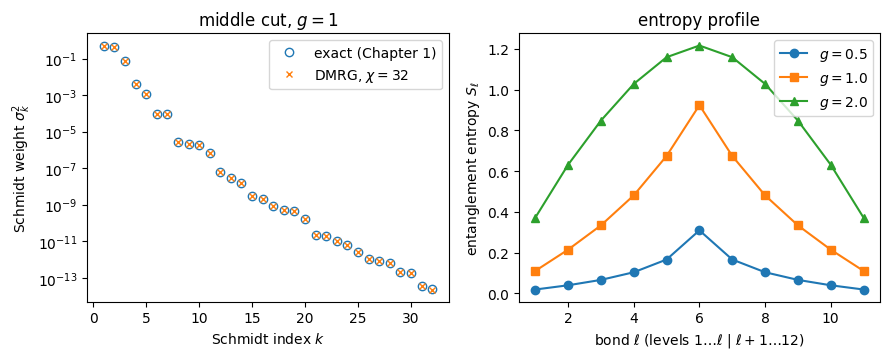

In [7]:
couplings = (0.5, 1.0, 2.0)
profiles = {}
states_g = {}
for gg in couplings:
    if gg == 1.0:
        solver = pairing_runs[32]
    else:
        solver = dmrg_ground_state(pairing_terms(L, gg), L, N, chi_max=32, max_sweeps=10)
    profiles[gg] = solver.entropies.copy()
    states_g[gg] = solver
    print(f"g = {gg:3.1f}:  E = {solver.energy:.8f}   S(middle cut) = {solver.entropies[L // 2 - 1]:.4f}"
          f"   max S = {solver.entropies.max():.4f}")

sigma_dmrg = pairing_runs[32].mps.schmidt_values(L // 2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.0, 3.7))
k = np.arange(1, 33)
ax1.semilogy(k, sigma_exact[:32]**2, "o", mfc="none", ms=6, label="exact (Chapter 1)")
ax1.semilogy(k[:len(sigma_dmrg)], sigma_dmrg**2, "x", ms=5, label=r"DMRG, $\chi=32$")
ax1.set_xlabel(r"Schmidt index $k$")
ax1.set_ylabel(r"Schmidt weight $\sigma_k^2$")
ax1.set_title(r"middle cut, $g=1$")
ax1.legend()
bonds = np.arange(1, L)
for gg, mk in zip(couplings, ("o-", "s-", "^-")):
    ax2.plot(bonds, profiles[gg], mk, label=rf"$g={gg}$")
ax2.set_xlabel(r"bond $\ell$ (levels $1\ldots\ell$ | $\ell+1\ldots 12$)")
ax2.set_ylabel(r"entanglement entropy $S_\ell$")
ax2.set_title("entropy profile")
ax2.legend()
fig.tight_layout()
plt.show()

### Occupation numbers

The DMRG state conserves the particle number exactly (the penalty
enforces it), so the occupation numbers $\langle\hat n_p\rangle$ of the
twelve levels show the correlated smearing of the Fermi surface without
the number fluctuations of the BCS state of Chapter 6.

g = 0.5:  n_p = [1.9944 1.9923 1.9887 1.9818 1.9651 1.9006 0.0994 0.0349 0.0182 0.0113 0.0077 0.0056]   sum = 12.000000
g = 1.0:  n_p = [1.9534 1.9365 1.9084 1.8572 1.7499 1.4731 0.5269 0.2501 0.1428 0.0916 0.0635 0.0466]   sum = 12.000000
g = 2.0:  n_p = [1.7554 1.6932 1.6081 1.4907 1.3299 1.1201 0.8799 0.6701 0.5093 0.3919 0.3068 0.2446]   sum = 12.000000


g = 4.0:  n_p = [1.4607 1.3934 1.3178 1.2343 1.1438 1.0485 0.9515 0.8562 0.7657 0.6822 0.6066 0.5393]   sum = 12.000000


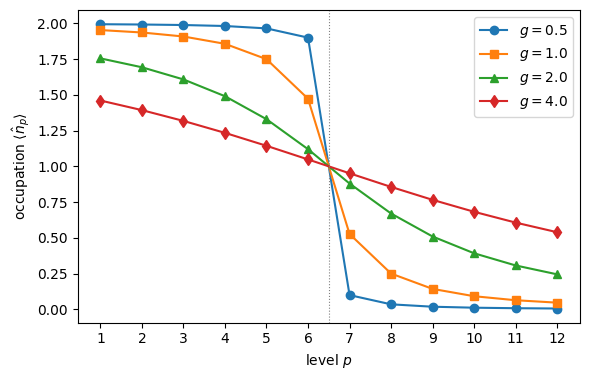

In [8]:
occ_couplings = (0.5, 1.0, 2.0, 4.0)
occupations = {}
for gg in occ_couplings:
    solver = states_g.get(gg) or dmrg_ground_state(pairing_terms(L, gg), L, N,
                                                  chi_max=32, max_sweeps=10)
    occupations[gg] = np.array([
        solver.mps.expectation_terms(occupation_terms(p, 0) + occupation_terms(p, 1))
        for p in range(L)])
    print(f"g = {gg:3.1f}:  n_p =", np.round(occupations[gg], 4), f"  sum = {occupations[gg].sum():.6f}")

fig, ax = plt.subplots(figsize=(6.0, 3.9))
levels = np.arange(1, L + 1)
for gg, mk in zip(occ_couplings, ("o-", "s-", "^-", "d-")):
    ax.plot(levels, occupations[gg], mk, label=rf"$g={gg}$")
ax.axvline(6.5, color="gray", lw=0.8, ls=":")
ax.set_xlabel(r"level $p$")
ax.set_ylabel(r"occupation $\langle \hat n_p\rangle$")
ax.set_xticks(levels)
ax.legend()
fig.tight_layout()
plt.show()

## 4. The pairing plus particle-hole model

The particle-hole interaction of Chapter 7 breaks pairs, so the ground
state is no longer of seniority zero and the exact diagonalisation has to
be done in the full $S_z=0$ sector.  Four levels and four particles first,
at the couplings of Chapter 7.

In [9]:
L, N = 4, 4
print(f"{'g':>6s} {'f':>6s} {'E_exact':>14s} {'E_DMRG':>14s} {'error':>10s}")
for g, f in ((0.5, 0.025), (0.7, 0.05), (1.0, 0.05), (1.0, 0.5)):
    terms = add_terms(pairing_terms(L, g), particle_hole_terms(L, f))
    e_ed = exact_ground_state(terms, L, N)
    solver = dmrg_ground_state(terms, L, N, chi_max=16)
    print(f"{g:6.2f} {f:6.3f} {e_ed:14.8f} {solver.energy:14.8f} {solver.energy - e_ed:10.1e}")

     g      f        E_exact         E_DMRG      error


  0.50  0.025     1.34713265     1.34713265    2.4e-15


  0.70  0.050     0.96975878     0.96975878   -1.5e-14


  1.00  0.050     0.45058234     0.45058234    4.6e-15


  1.00  0.500    -1.69173670    -1.69173670   -8.0e-15


Eight levels and eight particles, $g=1$, $f=0.5$: the $S_z=0$ sector has
$\binom{8}{4}^2=4900$ determinants and is still within reach of exact
diagonalisation, so we can follow the DMRG error as a function of $\chi$.
The error is variational, falls by about an order of magnitude per
doubling of $\chi$, and is proportional to the discarded weight -- which
is what makes the extrapolation to zero discarded weight the standard way
of quoting a DMRG energy.

In [10]:
L, N = 8, 8
g, f = 1.0, 0.5
terms = add_terms(pairing_terms(L, g), particle_hole_terms(L, f))
print(f"full N = 8 sector: {len(sector_states(L, N))} determinants, "
      f"S_z = 0 sector: {len(sector_states(L, N, N // 2))}")
e_ed = exact_ground_state(terms, L, N, n_a=N // 2)
print(f"exact: E = {e_ed:.10f}")
chis = (4, 8, 16, 32, 64)
ph = {"E": [], "eps": [], "S": []}
print(f"{'chi':>4s} {'E_DMRG':>16s} {'error':>10s} {'discarded':>10s} {'S(middle)':>10s} {'time':>8s}")
for chi in chis:
    t0 = time.time()
    solver = dmrg_ground_state(terms, L, N, chi_max=chi, max_sweeps=10)
    ph["E"].append(solver.energy); ph["eps"].append(solver.discarded[-1])
    ph["S"].append(solver.entropies[L // 2 - 1])
    print(f"{chi:4d} {solver.energy:16.10f} {solver.energy - e_ed:10.1e} "
          f"{solver.discarded[-1]:10.1e} {solver.entropies[L // 2 - 1]:10.4f} {time.time() - t0:7.1f}s")
E_chi, eps_chi = np.array(ph["E"]), np.array(ph["eps"])

full N = 8 sector: 12870 determinants, S_z = 0 sector: 4900


exact: E = 1.8291066715
 chi           E_DMRG      error  discarded  S(middle)     time


   4     2.2435302961    4.1e-01    9.1e-03     1.0114     0.7s


   8     1.8655652393    3.6e-02    1.2e-03     1.0898     2.6s


  16     1.8326023377    3.5e-03    1.3e-04     1.1064     7.3s


  32     1.8291612166    5.5e-05    2.4e-06     1.1084     7.6s


  64     1.8291067166    4.5e-08    2.2e-09     1.1084    11.9s


extrapolated energy from chi = 16, 32, 64: 1.82910168   error -5.0e-06
extrapolated energy from chi = 32, 64:     1.82910667   error -4.6e-09
extrapolated energy from chi = 4, 8, 16:   1.81943878   error -9.7e-03  (the cheap runs are off the line)
ratio  error / discarded weight: [45.8 31.5 26.8 22.7 20.6]


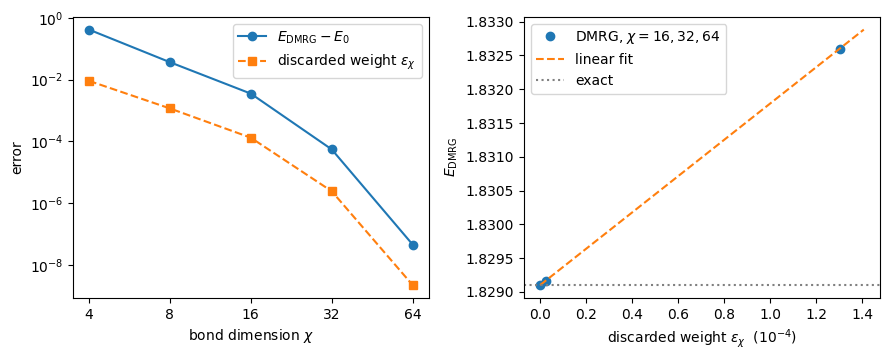

In [11]:
# straight-line extrapolation in the discarded weight through the three
# runs with the smallest discarded weights (the converged tail)
a, b = np.polyfit(eps_chi[2:], E_chi[2:], 1)
a2, b2 = np.polyfit(eps_chi[3:], E_chi[3:], 1)
a0, b0 = np.polyfit(eps_chi[:3], E_chi[:3], 1)
print(f"extrapolated energy from chi = 16, 32, 64: {b:.8f}   error {b - e_ed:.1e}")
print(f"extrapolated energy from chi = 32, 64:     {b2:.8f}   error {b2 - e_ed:.1e}")
print(f"extrapolated energy from chi = 4, 8, 16:   {b0:.8f}   error {b0 - e_ed:.1e}  (the cheap runs are off the line)")
print(f"ratio  error / discarded weight:", np.round((E_chi - e_ed) / eps_chi, 1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.0, 3.7))
ax1.semilogy(chis, E_chi - e_ed, "o-", label=r"$E_{\rm DMRG}-E_0$")
ax1.semilogy(chis, eps_chi, "s--", label=r"discarded weight $\epsilon_\chi$")
ax1.set_xscale("log", base=2)
ax1.set_xticks(chis); ax1.set_xticklabels([str(c) for c in chis])
ax1.set_xlabel(r"bond dimension $\chi$")
ax1.set_ylabel("error")
ax1.legend()
scale = 1e4
xs = np.linspace(0, eps_chi[2] * 1.08, 50)
ax2.plot(scale * eps_chi[2:], E_chi[2:], "o", label=r"DMRG, $\chi=16,32,64$")
ax2.plot(scale * xs, a * xs + b, "--", label="linear fit")
ax2.axhline(e_ed, color="gray", ls=":", label="exact")
ax2.set_xlabel(r"discarded weight $\epsilon_\chi$  ($10^{-4}$)")
ax2.set_ylabel(r"$E_{\rm DMRG}$")
ax2.legend()
fig.tight_layout()
plt.show()

## 5. The Hubbard chain

### The four-site ring of Chapter 4

A ring is awkward for an MPS -- the bond between the last and the first
site is carried through the whole chain -- but for four sites $\chi=16$
is exact and the DMRG reproduces every entry of Table 4.3, energies and
double occupancies alike.  ($U=0$ is left out: the half-filled free ring
has a degenerate ground state and its double occupancy is not unique.)

In [12]:
table = {2: -2.82842712, 4: -2.10274848, 8: -1.32023496, 16: -0.72286432}
L, N = 4, 4
print(f"{'U/t':>5s} {'E_0 (table)':>14s} {'E_DMRG':>14s} {'error':>10s} {'double occ.':>12s}")
for U in (2, 4, 8, 16):
    terms = hubbard_terms(L, 1.0, float(U), pbc=True)
    solver = dmrg_ground_state(terms, L, N, chi_max=16)
    docc = sum(solver.mps.expectation_terms(
        [(1.0, [(mode(i, 0), True), (mode(i, 0), False),
                (mode(i, 1), True), (mode(i, 1), False)])]) for i in range(L))
    print(f"{U:5d} {table[U]:14.8f} {solver.energy:14.8f} {solver.energy - table[U]:10.1e} {docc:12.6f}")

  U/t    E_0 (table)         E_DMRG      error  double occ.
    2    -2.82842712    -2.82842712   -4.7e-09     0.453082
    4    -2.10274848    -2.10274848   -3.5e-09     0.287325
    8    -1.32023496    -1.32023496    1.7e-09     0.129992


   16    -0.72286432    -0.72286432   -2.4e-09     0.042033


### Open chains: towards the thermodynamic limit

With open ends the chain is what the MPS wants, and we can leave exact
diagonalisation behind.  The check that replaces it is the Bethe ansatz:
Lieb and Wu solved the infinite half-filled chain exactly, with the energy
per site

$$e_\infty(U)=-4t\int_0^\infty
  \frac{J_0(\omega)J_1(\omega)}{\omega\,(1+e^{\omega U/2t})}\,d\omega ,$$

which at $U=4t$ is $-0.573729$.  An open chain has two ends, each raising
the energy by a fixed amount, so $E/L\to e_\infty+a/L+b/L^2$.  The runs
below take a few minutes; the $L=32$ chain at $\chi=32$ is the most
expensive.

In [13]:
e_inf = lieb_wu_energy(4.0)
print(f"Lieb-Wu energy per site of the infinite chain at U = 4t: {e_inf:.6f}")
sizes = (4, 8, 12, 16, 20, 24, 32)
hub = {}
print(f"{'L':>4s} {'E_exact':>14s} {'E_DMRG':>14s} {'E/L':>10s} {'discarded':>10s} {'S(middle)':>10s} {'time':>8s}")
for L in sizes:
    chi = 16 if L == 4 else 32
    terms = hubbard_terms(L, 1.0, 4.0)
    t0 = time.time()
    solver = dmrg_ground_state(terms, L, L, chi_max=chi, max_sweeps=10)
    hub[L] = solver
    if L <= 8:
        e_ed = exact_ground_state(terms, L, L, n_a=L // 2)
        ed = f"{e_ed:14.8f}"
    else:
        ed = f"{'--':>14s}"
    print(f"{L:4d} {ed} {solver.energy:14.8f} {solver.energy / L:10.6f} "
          f"{solver.discarded[-1]:10.1e} {solver.entropies[L // 2 - 1]:10.4f} {time.time() - t0:7.1f}s")

Lieb-Wu energy per site of the infinite chain at U = 4t: -0.573729
   L        E_exact         E_DMRG        E/L  discarded  S(middle)     time


   4    -1.95314531    -1.95314531  -0.488286    0.0e+00     0.5969     0.1s


   8    -4.23580700    -4.23579335  -0.529474    1.7e-06     0.7814     6.1s


  12             --    -6.52613611  -0.543845    6.4e-06     0.8757    23.4s


  16             --    -8.81845095  -0.551153    1.2e-05     0.9362    38.1s


  20             --   -11.11152991  -0.555576    1.9e-05     0.9791    57.2s


  24             --   -13.40496912  -0.558540    2.5e-05     1.0108    72.9s


  32             --   -17.99217239  -0.562255    3.5e-05     1.0540   124.0s


The entanglement entropy of the Hubbard chain does not saturate with $L$:
the spin sector is gapless, and conformal field theory predicts for an
open critical chain the arc
$S_\ell=\tfrac{c}{6}\ln\big[\tfrac{2L}{\pi}\sin\tfrac{\pi\ell}{L}\big]+s_0$
with central charge $c=1$ (Calabrese and Cardy), superimposed on an
even-odd alternation between neighbouring bonds.  We fit only $s_0$, with
$c=1$ fixed, through the even bonds of the $L=32$ chain.

quadratic extrapolation of E/L in 1/L: -0.573542   Lieb-Wu: -0.573729   difference 1.9e-04
Calabrese-Cardy fit with c = 1 through the even bonds: s_0 = 0.5439, rms deviation 0.0171


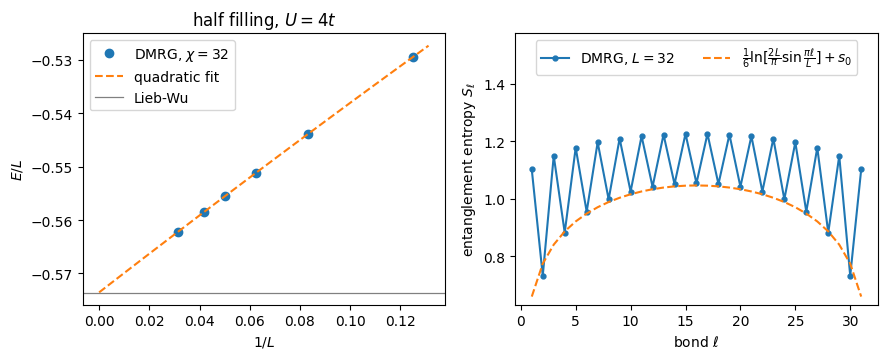

In [14]:
fit_sizes = [L for L in sizes if L >= 8]
x = np.array([1.0 / L for L in fit_sizes])
y = np.array([hub[L].energy / L for L in fit_sizes])
c2, c1, c0 = np.polyfit(x, y, 2)
print(f"quadratic extrapolation of E/L in 1/L: {c0:.6f}   Lieb-Wu: {e_inf:.6f}   "
      f"difference {c0 - e_inf:.1e}")

L = 32
S = hub[L].entropies
ell = np.arange(1, L)
arc = np.log(2 * L / np.pi * np.sin(np.pi * ell / L)) / 6.0
even = ell % 2 == 0
s0 = np.mean(S[even] - arc[even])
print(f"Calabrese-Cardy fit with c = 1 through the even bonds: s_0 = {s0:.4f}, "
      f"rms deviation {np.sqrt(np.mean((S[even] - arc[even] - s0)**2)):.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.0, 3.7))
xs = np.linspace(0, x.max() * 1.05, 100)
ax1.plot(x, y, "o", label=r"DMRG, $\chi=32$")
ax1.plot(xs, np.polyval((c2, c1, c0), xs), "--", label="quadratic fit")
ax1.axhline(e_inf, color="gray", ls="-", lw=0.9, label="Lieb-Wu")
ax1.set_xlabel(r"$1/L$")
ax1.set_ylabel(r"$E/L$")
ax1.set_title(r"half filling, $U=4t$")
ax1.legend()
ax2.plot(ell, S, "o-", ms=3.5, label=r"DMRG, $L=32$")
ax2.plot(ell, arc + s0, "--", label=r"$\frac{1}{6}\ln[\frac{2L}{\pi}\sin\frac{\pi\ell}{L}]+s_0$")
ax2.set_xlabel(r"bond $\ell$")
ax2.set_ylabel(r"entanglement entropy $S_\ell$")
ax2.set_ylim(top=S.max() + 0.35)
ax2.legend(loc="upper center", ncol=2)
fig.tight_layout()
plt.show()

## Exercises

The exercises of the chapter can all be done with the functions of this
notebook: the Schmidt spectrum and the entropy across every bond come from
`DMRG.entropies` and `MPS.schmidt_values`, the extrapolation in the
discarded weight from `DMRG.discarded`, and every observable from
`MPS.expectation_terms` with a term list in the same format as the
Hamiltonians.  Changing the order of the levels on the chain (put the
levels around the Fermi surface next to each other, or far apart) is a
matter of relabelling the sites in `pairing_terms`, and is the quickest way
to see that the bond dimension needed for a given accuracy depends on the
ordering as well as on the state.